## Modelling & EDA
### Intelligent DSS — Early Risk Prediction of Type 2 Diabetes

**Workflow**
1. Imports
2. Load & inspect data
3. Clean & encode
4. EDA (distributions, correlation, class balance)
5. Train / validation split (80 / 20 from train.csv)
6. Scale features
7. SMOTE — fix class imbalance
8. Model training & cross-validation comparison
9. Final model evaluation (test set)
10. SHAP explainability
11. Save artefacts

### 1. Imports

In [64]:
import warnings
warnings.filterwarnings("ignore")

import json
import pickle

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBClassifier

%matplotlib inline
print("All imports OK")


All imports OK


### Constants and Column list

In [2]:
RANDOM_STATE = 42
TARGET       = "diabetes_status"

# Columns we actually use (everything else is dropped)
KEEP_COLS = [
    "age", "sex", "is_pregnant",
    "bmi", "bmi_category", "residence",
    "family_history_diabetes", "previous_gdm",
    "physically_active", "has_hypertension",
    TARGET,
]

# Numeric columns that will be scaled
NUMERIC_COLS = [
    "age", "bmi",
]

# Categorical columns that need encoding
CATEGORICAL_COLS = [
    "sex", "is_pregnant", "bmi_category", "residence",
    "family_history_diabetes", "previous_gdm",
    "physically_active", "has_hypertension",
]

print("Constants set.")


Constants set.


### 2. Load Data

We use **train.csv** (10 000 records) and **test.csv** (2 000 records).   
We create our own clean 80/20 validation split from train.csv.

In [3]:
data_train = pd.read_csv("../data/01_raw/diabetes_train.csv")
data_test = pd.read_csv("../data/01_raw/diabetes_test.csv")


In [4]:
data_train.head()

,patient_id,age,sex,is_pregnant,residence,education,bmi,bmi_category,family_history_diabetes,previous_gdm,...,retinopathy,nephropathy,neuropathy,cardiovascular_disease,diabetic_foot_ulcer,preeclampsia,cesarean_delivery,macrosomic_baby,neonatal_hypoglycemia,nicu_admission
0,DM_000001,63.2,Female,False,Urban,NaN,26.9,Overweight,False,False,...,False,False,False,False,False,NaN,NaN,NaN,NaN,NaN
1,DM_000002,50.4,Male,False,Rural,Primary,23.3,Normal,False,False,...,False,False,False,False,False,NaN,NaN,NaN,NaN,NaN
2,DM_000003,57.7,Male,False,Urban,Primary,25.1,Overweight,False,False,...,False,False,False,False,False,NaN,NaN,NaN,NaN,NaN
3,DM_000004,77.1,Male,False,Urban,NaN,22.6,Normal,False,False,...,False,False,False,False,False,NaN,NaN,NaN,NaN,NaN
4,DM_000005,58.3,Male,False,Urban,Secondary,26.3,Overweight,False,False,...,False,False,False,False,False,NaN,NaN,NaN,NaN,NaN


In [5]:
data_test.head()

,patient_id,age,sex,is_pregnant,residence,education,bmi,bmi_category,family_history_diabetes,previous_gdm,...,retinopathy,nephropathy,neuropathy,cardiovascular_disease,diabetic_foot_ulcer,preeclampsia,cesarean_delivery,macrosomic_baby,neonatal_hypoglycemia,nicu_admission
0,DM_000001,59.4,Female,False,Rural,Secondary,23.1,Normal,False,False,...,False,False,False,False,False,NaN,NaN,NaN,NaN,NaN
1,DM_000002,49.1,Female,False,Rural,Secondary,32.4,Obese I,False,False,...,False,False,False,False,False,NaN,NaN,NaN,NaN,NaN
2,DM_000003,21.5,Male,False,Rural,Higher,17.0,Normal,False,False,...,False,False,False,False,False,NaN,NaN,NaN,NaN,NaN
3,DM_000004,50.0,Male,False,Rural,Higher,30.2,Obese I,False,False,...,False,False,False,False,False,NaN,NaN,NaN,NaN,NaN
4,DM_000005,49.8,Male,False,Urban,NaN,24.9,Normal,False,False,...,False,False,False,False,False,NaN,NaN,NaN,NaN,NaN


In [6]:
len(data_train), len(data_test)

(10000, 2000)

In [7]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 40 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               10000 non-null  object 
 1   age                      10000 non-null  float64
 2   sex                      10000 non-null  object 
 3   is_pregnant              10000 non-null  bool   
 4   residence                10000 non-null  object 
 5   education                8015 non-null   object 
 6   bmi                      10000 non-null  float64
 7   bmi_category             10000 non-null  object 
 8   family_history_diabetes  10000 non-null  bool   
 9   previous_gdm             10000 non-null  bool   
 10  physically_active        10000 non-null  bool   
 11  has_hypertension         10000 non-null  bool   
 12  parity                   142 non-null    float64
 13  previous_macrosomia      10000 non-null  bool   
 14  pcos                   

In [8]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 40 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               2000 non-null   object 
 1   age                      2000 non-null   float64
 2   sex                      2000 non-null   object 
 3   is_pregnant              2000 non-null   bool   
 4   residence                2000 non-null   object 
 5   education                1581 non-null   object 
 6   bmi                      2000 non-null   float64
 7   bmi_category             2000 non-null   object 
 8   family_history_diabetes  2000 non-null   bool   
 9   previous_gdm             2000 non-null   bool   
 10  physically_active        2000 non-null   bool   
 11  has_hypertension         2000 non-null   bool   
 12  parity                   41 non-null     float64
 13  previous_macrosomia      2000 non-null   bool   
 14  pcos                    

In [9]:
# Columns to KEEP for training dataset

columns_to_keep = [
    "age",
    "sex",
    "is_pregnant",
    "bmi",
    "bmi_category",
    "family_history_diabetes",
    "previous_gdm",
    "physically_active",
    "has_hypertension",
    "residence",
    "diabetes_status"   # Target column
]

# Keep only selected columns
data_train = data_train[columns_to_keep]

# Display first rows
print(data_train.head())

# Check dataset shape
print("\nDataset Shape:")
print(data_train.shape)

# Check missing values
print("\nMissing Values:")
print(data_train.isnull().sum())

# Save cleaned dataset
data_train.to_csv("../data/01_raw/cleaned_diabetes_train.csv", index=False)

print("\nCleaned dataset saved successfully.")

    age     sex  is_pregnant   bmi bmi_category  family_history_diabetes  \
0  63.2  Female        False  26.9   Overweight                    False   
1  50.4    Male        False  23.3       Normal                    False   
2  57.7    Male        False  25.1   Overweight                    False   
3  77.1    Male        False  22.6       Normal                    False   
4  58.3    Male        False  26.3   Overweight                    False   

   previous_gdm  physically_active  has_hypertension residence diabetes_status  
0         False               True              True     Urban        Diabetic  
1         False              False             False     Rural          Normal  
2         False              False             False     Urban        Diabetic  
3         False              False              True     Urban        Diabetic  
4         False               True              True     Urban        Diabetic  

Dataset Shape:
(10000, 11)

Missing Values:
age         

In [10]:
# Columns to KEEP for test dataset

columns_to_keep = [
    "age",
    "sex",
    "is_pregnant",
    "bmi",
    "bmi_category",
    "family_history_diabetes",
    "previous_gdm",
    "physically_active",
    "has_hypertension",
    "residence",
    "diabetes_status"   # Target column
]

# Keep only selected columns
data_test = data_test[columns_to_keep]

# Display first rows
print(data_test.head())

# Check dataset shape
print("\nDataset Shape:")
print(data_test.shape)

# Check missing values
print("\nMissing Values:")
print(data_test.isnull().sum())

# Save cleaned dataset
data_test.to_csv("../data/01_raw/cleaned_diabetes_test.csv", index=False)

print("\nCleaned test dataset saved successfully.")

    age     sex  is_pregnant   bmi bmi_category  family_history_diabetes  \
0  59.4  Female        False  23.1       Normal                    False   
1  49.1  Female        False  32.4      Obese I                    False   
2  21.5    Male        False  17.0       Normal                    False   
3  50.0    Male        False  30.2      Obese I                    False   
4  49.8    Male        False  24.9       Normal                    False   

   previous_gdm  physically_active  has_hypertension residence diabetes_status  
0         False              False             False     Rural        Diabetic  
1         False              False              True     Rural        Diabetic  
2         False              False              True     Rural     Prediabetes  
3         False               True             False     Rural        Diabetic  
4         False               True             False     Urban     Prediabetes  

Dataset Shape:
(2000, 11)

Missing Values:
age          

In [11]:


data_train_cleaned = pd.read_csv("../data/01_raw/cleaned_diabetes_train.csv")
data_test_cleaned = pd.read_csv("../data/01_raw/cleaned_diabetes_test.csv")

In [12]:
# check total duplicated rows

duplicates = data_train_cleaned.duplicated().sum()
duplicates_test = data_test_cleaned.duplicated().sum()

print(f"Total duplicated rows in training set: {duplicates}")
print(f"Total duplicated rows in test set: {duplicates_test}")

Total duplicated rows in training set: 23
Total duplicated rows in test set: 0


In [13]:
data_train_cleaned.dtypes

age                        float64
sex                         object
is_pregnant                   bool
bmi                        float64
bmi_category                object
family_history_diabetes       bool
previous_gdm                  bool
physically_active             bool
has_hypertension              bool
residence                   object
diabetes_status             object
dtype: object

In [14]:
data_test_cleaned.dtypes

age                        float64
sex                         object
is_pregnant                   bool
bmi                        float64
bmi_category                object
family_history_diabetes       bool
previous_gdm                  bool
physically_active             bool
has_hypertension              bool
residence                   object
diabetes_status             object
dtype: object

In [15]:
data_train_cleaned.describe()

,age,bmi
count,10000.000000,10000.000000
mean,51.819540,25.710250
std,11.875188,4.625272
min,18.000000,16.000000
25%,43.800000,22.400000
50%,51.900000,25.600000
75%,59.700000,28.800000
max,85.000000,45.000000


In [16]:
data_test_cleaned.describe()

,age,bmi
count,2000.000000,2000.000000
mean,51.629600,25.521200
std,12.171147,4.518716
min,18.000000,16.000000
25%,43.200000,22.400000
50%,51.600000,25.500000
75%,60.325000,28.425000
max,85.000000,42.100000


In [17]:
print("Target value counts — Train:")
print(data_train_cleaned[TARGET].value_counts())

Target value counts — Train:
diabetes_status
Diabetic       7458
Prediabetes    1339
Normal         1203
Name: count, dtype: int64


In [18]:
print("Target value counts — Test:")
print(data_test_cleaned[TARGET].value_counts())

Target value counts — Test:
diabetes_status
Diabetic       1477
Prediabetes     280
Normal          243
Name: count, dtype: int64


In [19]:
print("bmi_category value counts — Test:")
print(data_test_cleaned["bmi_category"].value_counts())

bmi_category value counts — Test:
bmi_category
Normal        892
Overweight    791
Obese I       263
Obese II+      54
Name: count, dtype: int64


In [20]:
print("bmi_category value counts — Train:")
print(data_train_cleaned["bmi_category"].value_counts())

bmi_category value counts — Train:
bmi_category
Normal        4484
Overweight    3726
Obese I       1528
Obese II+      262
Name: count, dtype: int64


In [21]:
print("residence value counts — Train:")
print(data_train_cleaned["residence"].value_counts())

residence value counts — Train:
residence
Rural    5454
Urban    4546
Name: count, dtype: int64


In [22]:
print("residence value counts — Test:")
print(data_test_cleaned["residence"].value_counts())

residence value counts — Test:
residence
Rural    1104
Urban     896
Name: count, dtype: int64


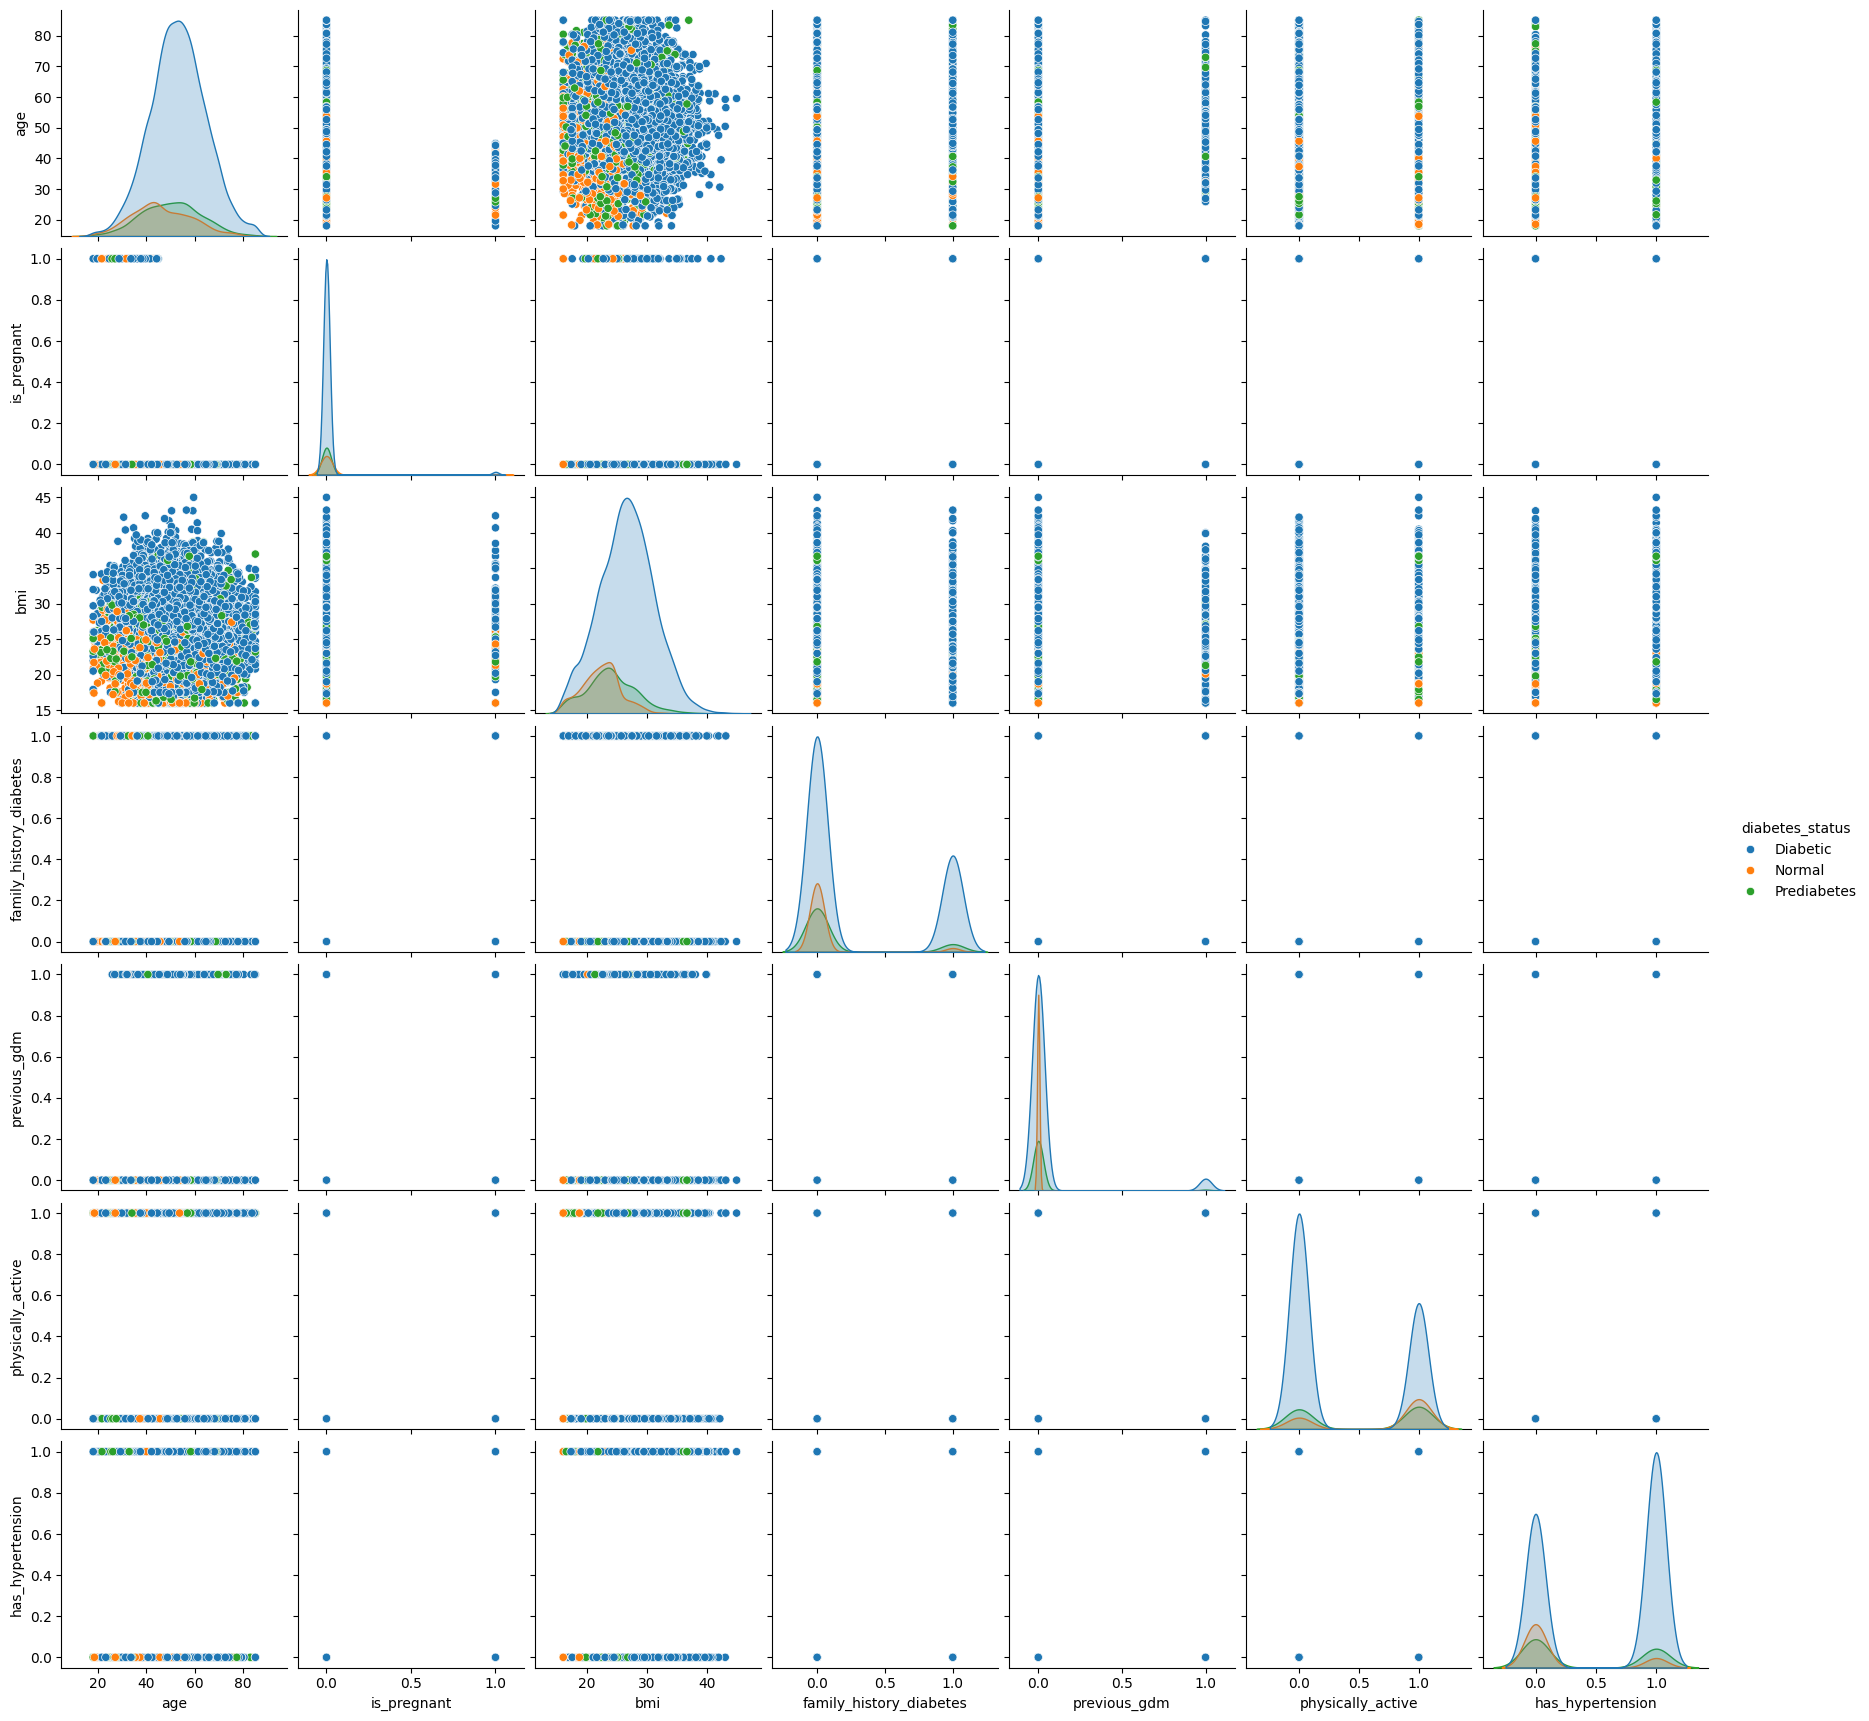

In [23]:
sns.pairplot(data_train_cleaned, hue="diabetes_status")
plt.show()

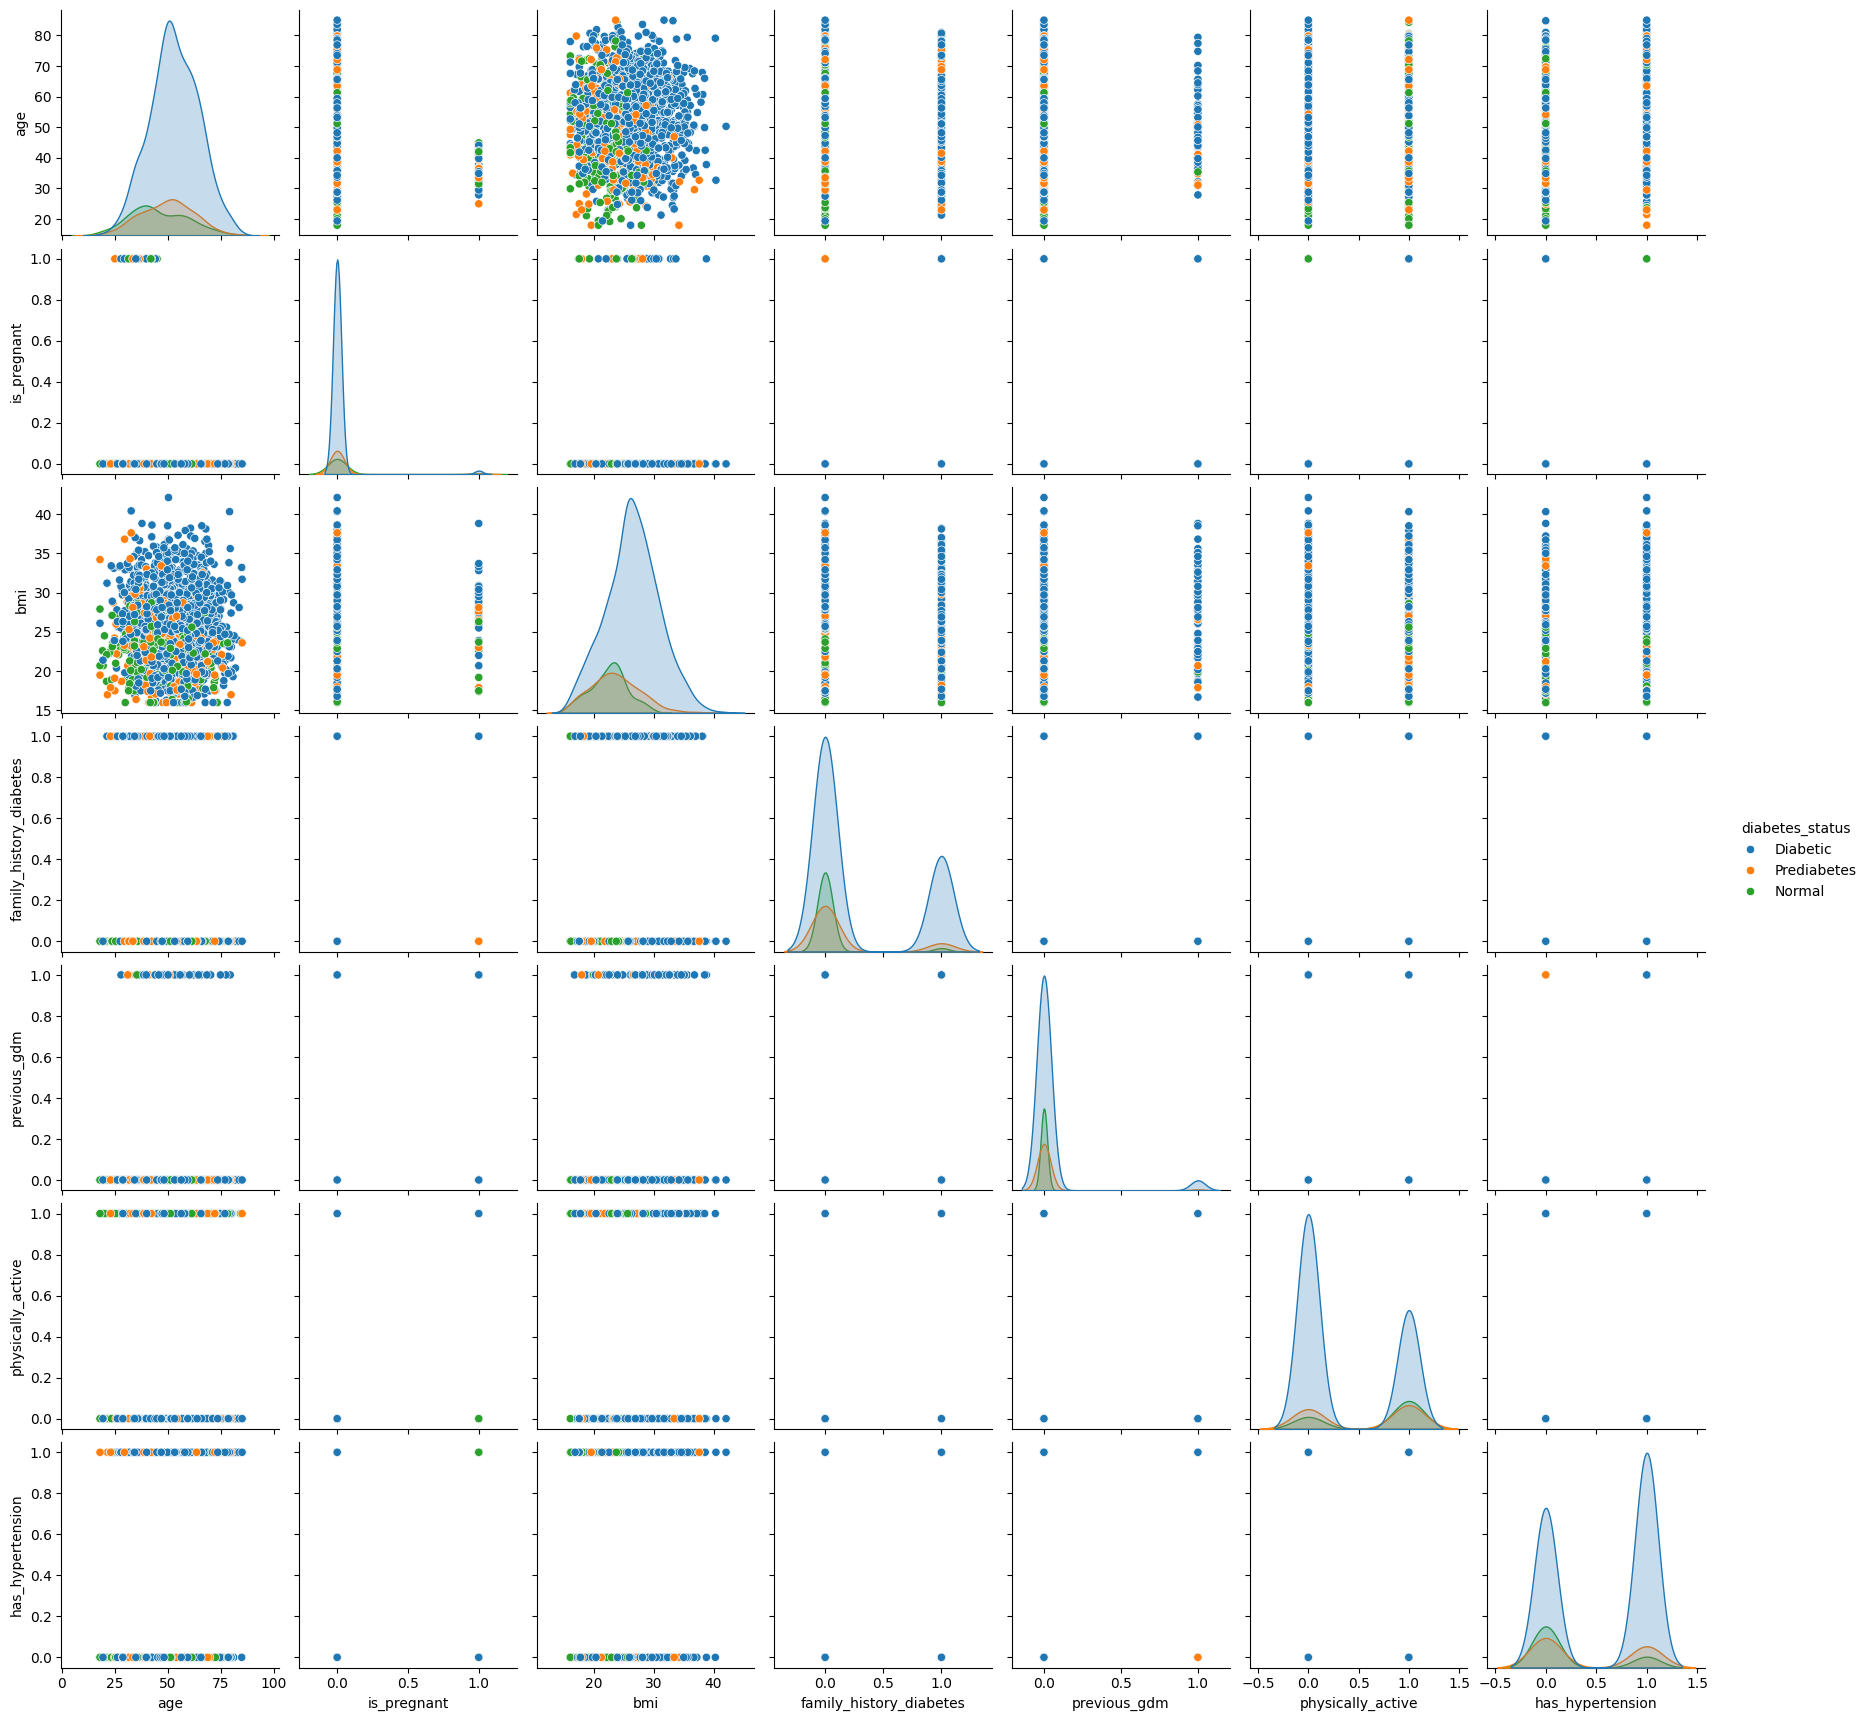

In [24]:
sns.pairplot(data_test_cleaned, hue="diabetes_status")
plt.show()

### Cleaning and Encoding

In [25]:
# Target — ordinal 3-class encoding
# Normal = 0, Prediabetes = 1, Diabetic = 2

TARGET_MAP = {
    "normal"     : 0,
    "prediabetes": 1,
    "diabetic"   : 2,
}

def encode_target(df):
    df = df.copy()
    df[TARGET] = (
        df[TARGET].astype(str).str.strip().str.lower()
        .map(TARGET_MAP)
    )
    return df

data_train_cleaned = encode_target(data_train_cleaned)
data_test_cleaned  = encode_target(data_test_cleaned)

print("Target after encoding:")
print(data_train_cleaned[TARGET].value_counts().sort_index())
print()
print("Expected:  0=Normal  1=Prediabetes  2=Diabetic")

Target after encoding:
diabetes_status
0    1203
1    1339
2    7458
Name: count, dtype: int64

Expected:  0=Normal  1=Prediabetes  2=Diabetic


In [26]:
data_train_cleaned.head()

,age,sex,is_pregnant,bmi,bmi_category,family_history_diabetes,previous_gdm,physically_active,has_hypertension,residence,diabetes_status
0,63.2,Female,False,26.9,Overweight,False,False,True,True,Urban,2
1,50.4,Male,False,23.3,Normal,False,False,False,False,Rural,0
2,57.7,Male,False,25.1,Overweight,False,False,False,False,Urban,2
3,77.1,Male,False,22.6,Normal,False,False,False,True,Urban,2
4,58.3,Male,False,26.3,Overweight,False,False,True,True,Urban,2


In [27]:
data_test_cleaned.head()

,age,sex,is_pregnant,bmi,bmi_category,family_history_diabetes,previous_gdm,physically_active,has_hypertension,residence,diabetes_status
0,59.4,Female,False,23.1,Normal,False,False,False,False,Rural,2
1,49.1,Female,False,32.4,Obese I,False,False,False,True,Rural,2
2,21.5,Male,False,17.0,Normal,False,False,False,True,Rural,1
3,50.0,Male,False,30.2,Obese I,False,False,True,False,Rural,2
4,49.8,Male,False,24.9,Normal,False,False,True,False,Urban,1


In [28]:
# Boolean columns → 0 / 1
BOOL_COLS = [
    "is_pregnant", "family_history_diabetes",
    "previous_gdm", "physically_active", "has_hypertension",
]

def encode_booleans(df):
    df = df.copy()
    for col in BOOL_COLS:
        if col in df.columns:
            df[col] = (
                df[col].astype(str).str.strip().str.lower()
                .map({"true": 1, "false": 0, "yes": 1, "no": 0, "1": 1, "0": 0})
                .astype(int)
            )
    return df

data_train_cleaned = encode_booleans(data_train_cleaned)
data_test_cleaned  = encode_booleans(data_test_cleaned)

print("Boolean columns encoded.")
data_train_cleaned[BOOL_COLS].head(3)

Boolean columns encoded.


,is_pregnant,family_history_diabetes,previous_gdm,physically_active,has_hypertension
0,0,0,0,1,1
1,0,0,0,0,0
2,0,0,0,0,0


In [29]:
data_train_cleaned.head()

,age,sex,is_pregnant,bmi,bmi_category,family_history_diabetes,previous_gdm,physically_active,has_hypertension,residence,diabetes_status
0,63.2,Female,0,26.9,Overweight,0,0,1,1,Urban,2
1,50.4,Male,0,23.3,Normal,0,0,0,0,Rural,0
2,57.7,Male,0,25.1,Overweight,0,0,0,0,Urban,2
3,77.1,Male,0,22.6,Normal,0,0,0,1,Urban,2
4,58.3,Male,0,26.3,Overweight,0,0,1,1,Urban,2


In [30]:
data_test_cleaned.head()

,age,sex,is_pregnant,bmi,bmi_category,family_history_diabetes,previous_gdm,physically_active,has_hypertension,residence,diabetes_status
0,59.4,Female,0,23.1,Normal,0,0,0,0,Rural,2
1,49.1,Female,0,32.4,Obese I,0,0,0,1,Rural,2
2,21.5,Male,0,17.0,Normal,0,0,0,1,Rural,1
3,50.0,Male,0,30.2,Obese I,0,0,1,0,Rural,2
4,49.8,Male,0,24.9,Normal,0,0,1,0,Urban,1


In [31]:
# bmi_category — ordinal
# Normal = 0, Overweight = 1, Obese I = 2, Obese II+ = 3

BMI_MAP = {
    "normal"    : 0,
    "overweight": 1,
    "obese i"   : 2,
    "obese ii+" : 3,
}

def encode_bmi_category(df):
    df = df.copy()
    df["bmi_category"] = (
        df["bmi_category"].astype(str).str.strip().str.lower()
        .map(BMI_MAP)
        .astype(int)
    )
    return df

data_train_cleaned = encode_bmi_category(data_train_cleaned)
data_test_cleaned  = encode_bmi_category(data_test_cleaned)

print("bmi_category unique values:", sorted(data_train_cleaned["bmi_category"].unique()))
print("Expected: [0, 1, 2, 3]")

bmi_category unique values: [0, 1, 2, 3]
Expected: [0, 1, 2, 3]


In [32]:
data_train_cleaned.head()

,age,sex,is_pregnant,bmi,bmi_category,family_history_diabetes,previous_gdm,physically_active,has_hypertension,residence,diabetes_status
0,63.2,Female,0,26.9,1,0,0,1,1,Urban,2
1,50.4,Male,0,23.3,0,0,0,0,0,Rural,0
2,57.7,Male,0,25.1,1,0,0,0,0,Urban,2
3,77.1,Male,0,22.6,0,0,0,0,1,Urban,2
4,58.3,Male,0,26.3,1,0,0,1,1,Urban,2


In [33]:
data_test_cleaned.head()

,age,sex,is_pregnant,bmi,bmi_category,family_history_diabetes,previous_gdm,physically_active,has_hypertension,residence,diabetes_status
0,59.4,Female,0,23.1,0,0,0,0,0,Rural,2
1,49.1,Female,0,32.4,2,0,0,0,1,Rural,2
2,21.5,Male,0,17.0,0,0,0,0,1,Rural,1
3,50.0,Male,0,30.2,2,0,0,1,0,Rural,2
4,49.8,Male,0,24.9,0,0,0,1,0,Urban,1


In [34]:
# sex → Female = 0, Male = 1
SEX_MAP = {"female": 0, "male": 1}

def encode_sex(df):
    df = df.copy()
    df["sex"] = (
        df["sex"].astype(str).str.strip().str.lower()
        .map(SEX_MAP)
        .astype(int)
    )
    return df

data_train_cleaned = encode_sex(data_train_cleaned)
data_test_cleaned  = encode_sex(data_test_cleaned)

print("sex unique values:", sorted(data_train_cleaned["sex"].unique()))
print("Expected: [0, 1]  (0=Female, 1=Male)")

sex unique values: [0, 1]
Expected: [0, 1]  (0=Female, 1=Male)


In [35]:
data_train_cleaned.head()

,age,sex,is_pregnant,bmi,bmi_category,family_history_diabetes,previous_gdm,physically_active,has_hypertension,residence,diabetes_status
0,63.2,0,0,26.9,1,0,0,1,1,Urban,2
1,50.4,1,0,23.3,0,0,0,0,0,Rural,0
2,57.7,1,0,25.1,1,0,0,0,0,Urban,2
3,77.1,1,0,22.6,0,0,0,0,1,Urban,2
4,58.3,1,0,26.3,1,0,0,1,1,Urban,2


In [36]:
data_test_cleaned.head()

,age,sex,is_pregnant,bmi,bmi_category,family_history_diabetes,previous_gdm,physically_active,has_hypertension,residence,diabetes_status
0,59.4,0,0,23.1,0,0,0,0,0,Rural,2
1,49.1,0,0,32.4,2,0,0,0,1,Rural,2
2,21.5,1,0,17.0,0,0,0,0,1,Rural,1
3,50.0,1,0,30.2,2,0,0,1,0,Rural,2
4,49.8,1,0,24.9,0,0,0,1,0,Urban,1


In [37]:
# residence → Rural = 0, Urban = 1
RESIDENCE_MAP = {"rural": 0, "urban": 1}

def encode_residence(df):
    df = df.copy()
    df["residence"] = (
        df["residence"].astype(str).str.strip().str.lower()
        .map(RESIDENCE_MAP)
        .astype(int)
    )
    return df

data_train_cleaned = encode_residence(data_train_cleaned)
data_test_cleaned  = encode_residence(data_test_cleaned)

print("residence unique values:", sorted(data_train_cleaned["residence"].unique()))
print("Expected: [0, 1]  (0=Rural, 1=Urban)")

residence unique values: [0, 1]
Expected: [0, 1]  (0=Rural, 1=Urban)


In [38]:
# Age: convert float to int
# Age values like 33.2, 44.6 are truncated to whole years (floor).

def convert_age(df):
    df = df.copy()
    df["age"] = df["age"].astype(float).astype(int)
    return df

data_train_cleaned = convert_age(data_train_cleaned)
data_test_cleaned  = convert_age(data_test_cleaned)

print("Age after conversion (train sample):", data_train_cleaned["age"].head(8).tolist())
print("Age dtype:", data_train_cleaned["age"].dtype)

# Final data quality check
# Rename to data_train_cleaned_1 and data_test_cleaned_1 for consistency with downstream cells.

data_train_cleaned_1 = data_train_cleaned.copy()
data_test_cleaned_1  = data_test_cleaned.copy()

print()
print(f"Nulls in train : {data_train_cleaned_1.isnull().sum().sum()}")
print(f"Nulls in test  : {data_test_cleaned_1.isnull().sum().sum()}")
print()
print("Final dtypes:")
print(data_train_cleaned_1.dtypes)

Age after conversion (train sample): [63, 50, 57, 77, 58, 55, 39, 50]
Age dtype: int32

Nulls in train : 0
Nulls in test  : 0

Final dtypes:
age                          int32
sex                          int32
is_pregnant                  int32
bmi                        float64
bmi_category                 int32
family_history_diabetes      int32
previous_gdm                 int32
physically_active            int32
has_hypertension             int32
residence                    int32
diabetes_status              int64
dtype: object


In [39]:
data_train_cleaned_1.head()

,age,sex,is_pregnant,bmi,bmi_category,family_history_diabetes,previous_gdm,physically_active,has_hypertension,residence,diabetes_status
0,63,0,0,26.9,1,0,0,1,1,1,2
1,50,1,0,23.3,0,0,0,0,0,0,0
2,57,1,0,25.1,1,0,0,0,0,1,2
3,77,1,0,22.6,0,0,0,0,1,1,2
4,58,1,0,26.3,1,0,0,1,1,1,2


In [40]:
data_test_cleaned_1.head()

,age,sex,is_pregnant,bmi,bmi_category,family_history_diabetes,previous_gdm,physically_active,has_hypertension,residence,diabetes_status
0,59,0,0,23.1,0,0,0,0,0,0,2
1,49,0,0,32.4,2,0,0,0,1,0,2
2,21,1,0,17.0,0,0,0,0,1,0,1
3,50,1,0,30.2,2,0,0,1,0,0,2
4,49,1,0,24.9,0,0,0,1,0,1,1


### EDA(Exploratory Data Analysis)

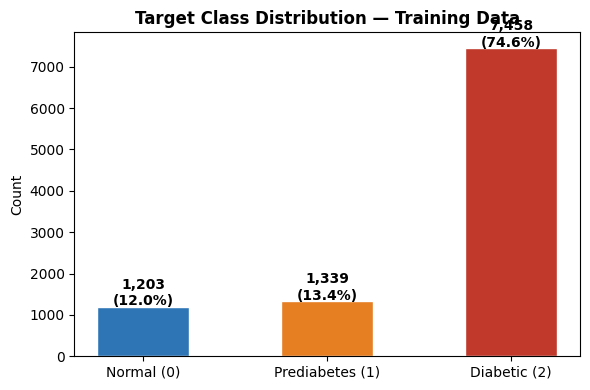

In [41]:
# Class distribution

counts = data_train_cleaned_1[TARGET].value_counts().sort_index()
labels = ["Normal (0)", "Prediabetes (1)", "Diabetic (2)"]
colors = ["#2E75B6", "#E67E22", "#C0392B"]
pcts   = (counts / len(data_train_cleaned_1) * 100).round(1)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, counts.values, color=colors, edgecolor="white", width=0.5)
for bar, pct, n in zip(bars, pcts.values, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{n:,}\n({pct}%)", ha="center", fontsize=10, fontweight="bold")
ax.set_title("Target Class Distribution — Training Data", fontweight="bold")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

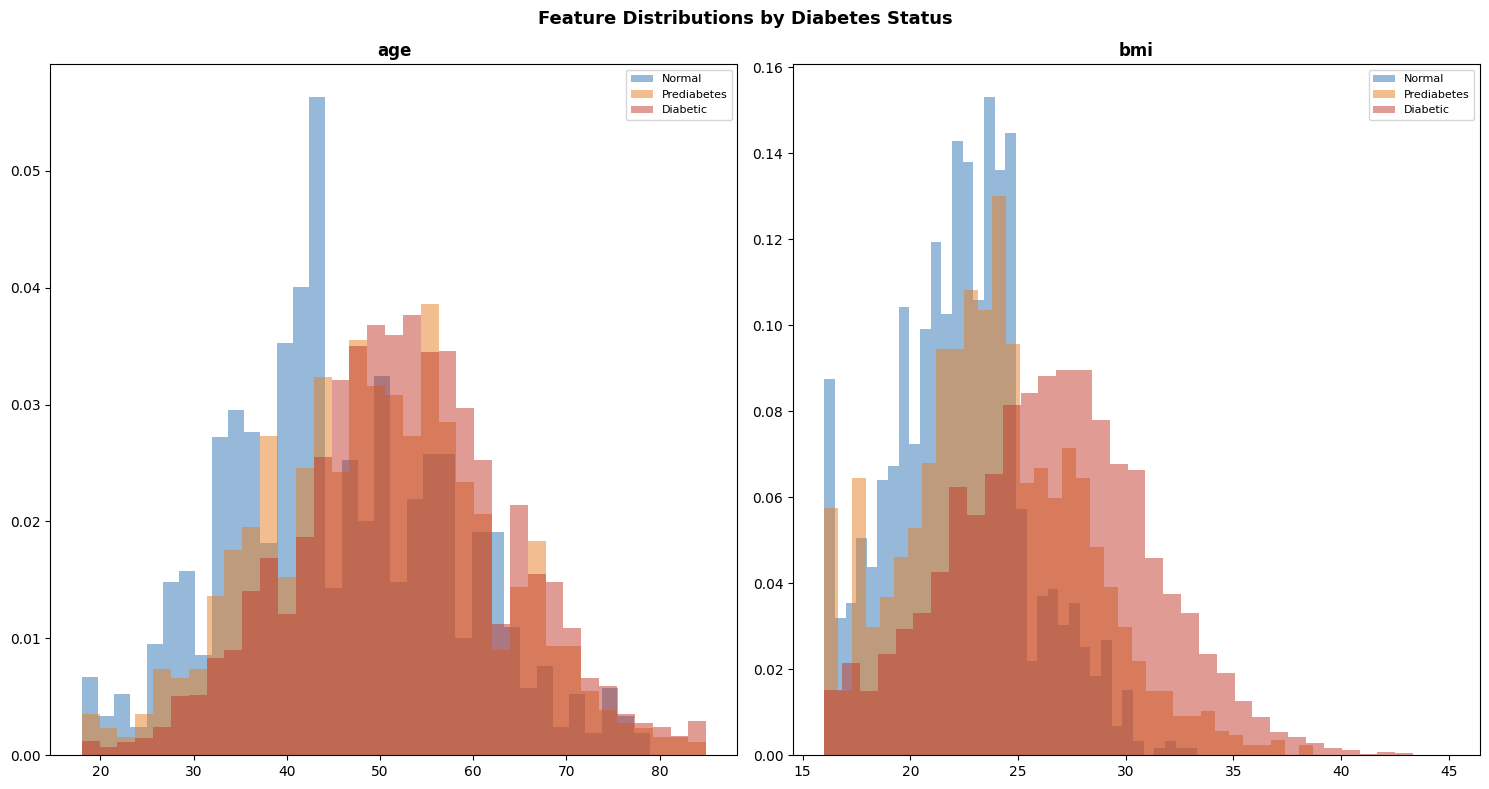

In [42]:
# Distribution of numeric features split by target

key_cols = ["age", "bmi"]

key_cols = [c for c in key_cols if c in data_train_cleaned_1.columns]

fig, axes = plt.subplots(1, 2, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(key_cols):
    ax = axes[i]
    for cls, color, label in [(0, "#2E75B6", "Normal"),
                               (1, "#E67E22", "Prediabetes"),
                               (2, "#C0392B", "Diabetic")]:
        data = data_train_cleaned_1.loc[data_train_cleaned_1[TARGET] == cls, col].dropna()
        ax.hist(data, bins=35, alpha=0.5, color=color,
                label=label, edgecolor="none", density=True)
    ax.set_title(col, fontweight="bold")
    ax.legend(fontsize=8)

plt.suptitle("Feature Distributions by Diabetes Status", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

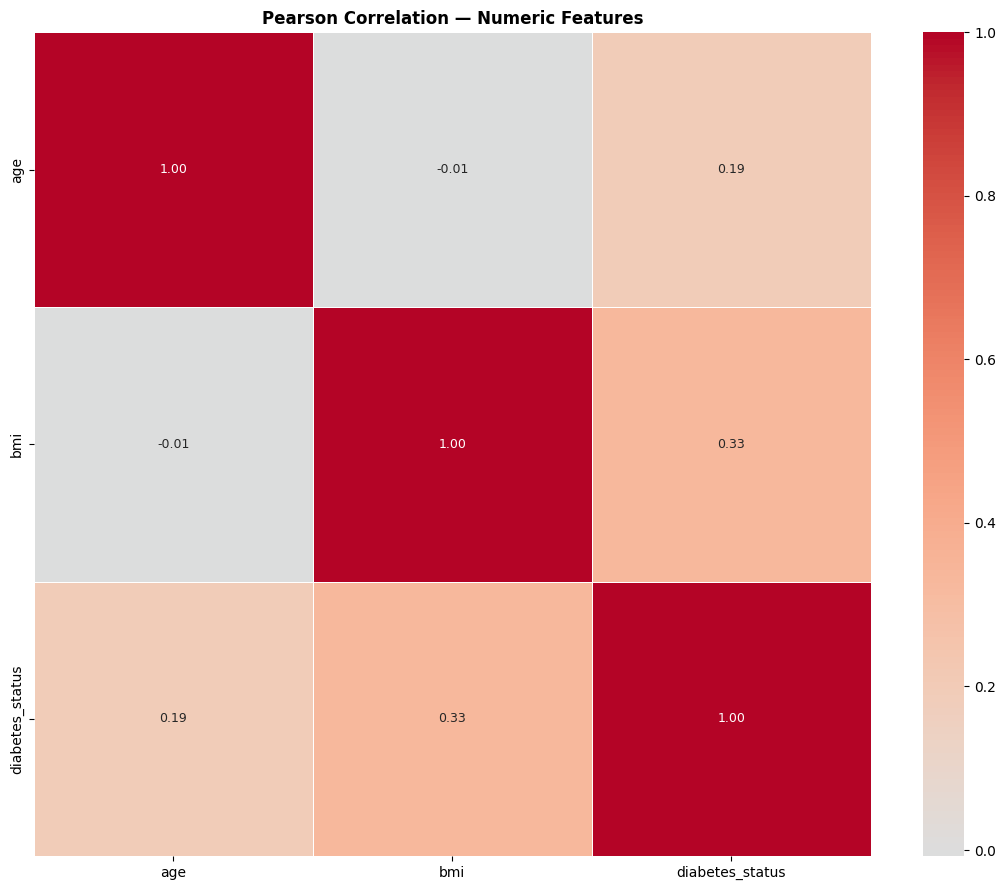

In [43]:
# Correlation heatmap

numeric_in = [c for c in NUMERIC_COLS if c in data_train_cleaned_1.columns] + [TARGET]
corr = data_train_cleaned_1[numeric_in].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.4, annot_kws={"size": 9})
plt.title("Pearson Correlation — Numeric Features", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

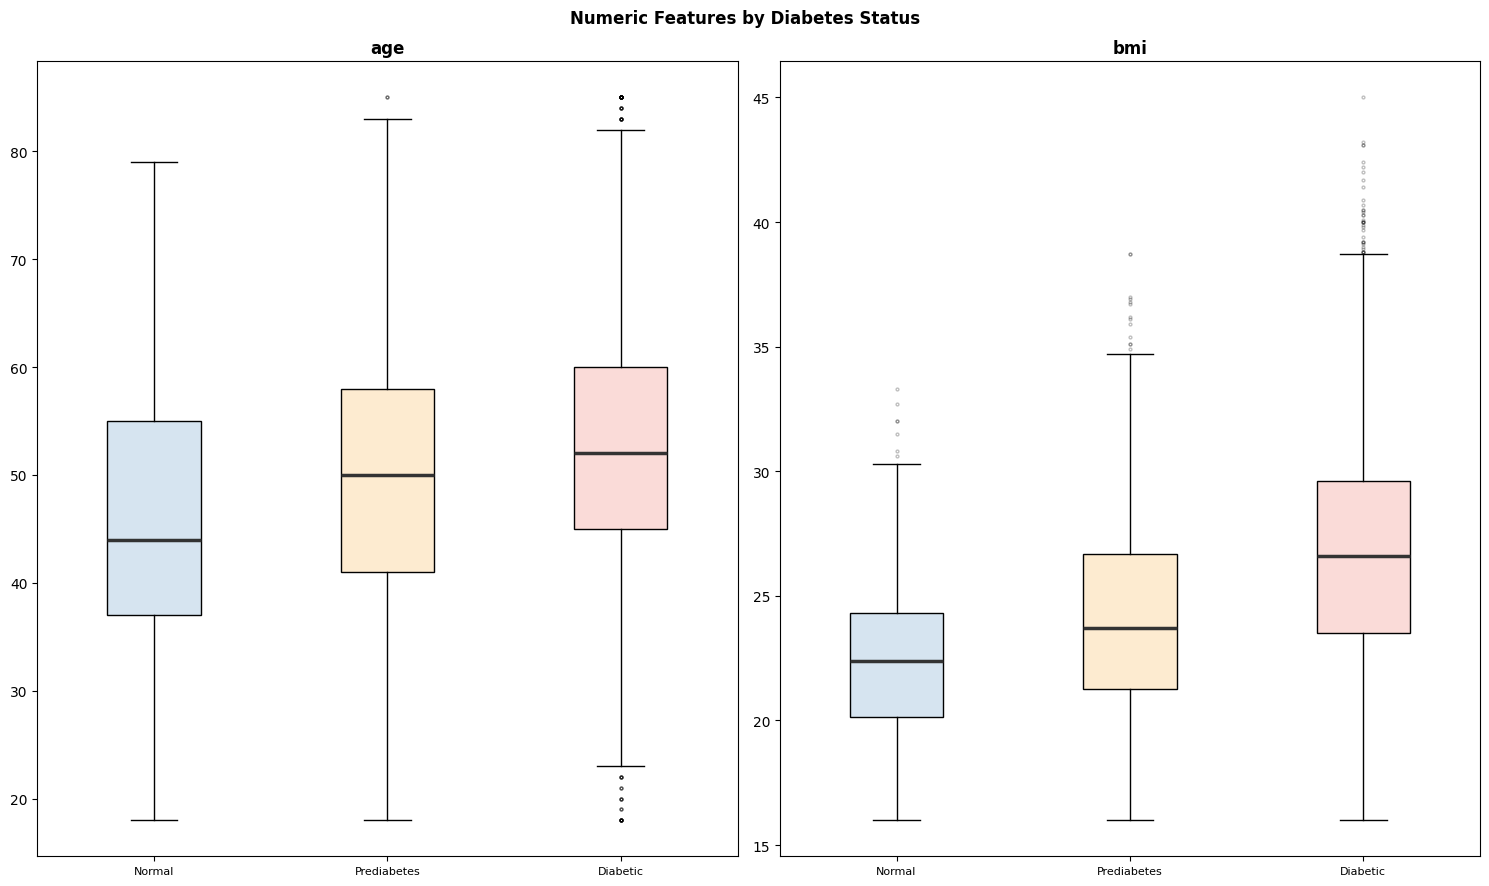

In [44]:
# Boxplots: key numeric features vs target (3 classes)

fig, axes = plt.subplots(1, 2, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(key_cols):
    ax = axes[i]
    d0 = data_train_cleaned_1.loc[data_train_cleaned_1[TARGET] == 0, col].dropna()
    d1 = data_train_cleaned_1.loc[data_train_cleaned_1[TARGET] == 1, col].dropna()
    d2 = data_train_cleaned_1.loc[data_train_cleaned_1[TARGET] == 2, col].dropna()
    bp = ax.boxplot([d0, d1, d2], patch_artist=True,
                    labels=["Normal", "Prediabetes", "Diabetic"], widths=0.4,
                    medianprops=dict(color="#333333", linewidth=2.5),
                    flierprops=dict(marker="o", markersize=2, alpha=0.25))

    bp["boxes"][0].set_facecolor("#D6E4F0")
    bp["boxes"][1].set_facecolor("#FDEBD0")
    bp["boxes"][2].set_facecolor("#FADBD8")
    ax.set_title(col, fontweight="bold")
    ax.tick_params(axis="x", labelsize=8)

plt.suptitle("Numeric Features by Diabetes Status", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

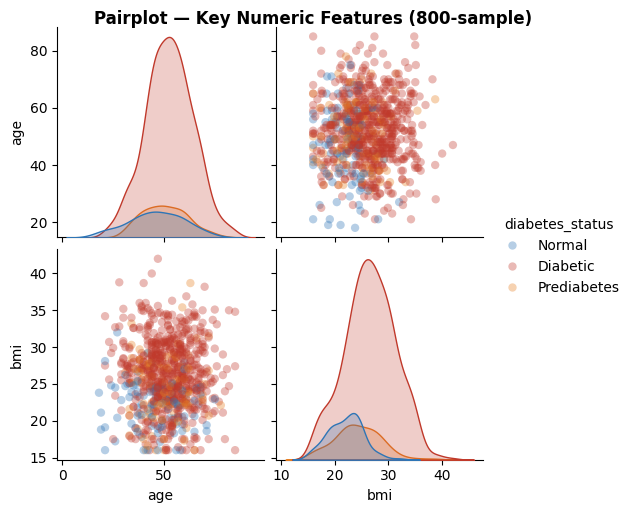

In [45]:
# Pairplot (sampled for speed)

sample = data_train_cleaned_1[key_cols + [TARGET]].sample(800, random_state=RANDOM_STATE)
sample[TARGET] = sample[TARGET].map({0: "Normal", 1: "Prediabetes", 2: "Diabetic"})
sns.pairplot(sample, hue=TARGET,
             palette={"Normal": "#2E75B6", "Prediabetes": "#E67E22", "Diabetic": "#C0392B"},
             plot_kws={"alpha": 0.35, "edgecolor": "none"}, diag_kind="kde")
plt.suptitle("Pairplot — Key Numeric Features (800-sample)", y=1.01, fontweight="bold")
plt.show()

### Train/Validation Split

In [46]:
FEATURE_COLS = [c for c in KEEP_COLS if c != TARGET]

X = data_train_cleaned_1[FEATURE_COLS].values.astype(float)
y = data_train_cleaned_1[TARGET].values.astype(int)

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_test = data_test_cleaned_1[FEATURE_COLS].values.astype(float)
y_test = data_test_cleaned_1[TARGET].values.astype(int)

print(f"X_train : {X_train.shape}   class dist: {np.bincount(y_train)}")
print(f"X_val   : {X_val.shape}   class dist: {np.bincount(y_val)}")
print(f"X_test  : {X_test.shape}   class dist: {np.bincount(y_test)}")


X_train : (8000, 10)   class dist: [ 962 1071 5967]
X_val   : (2000, 10)   class dist: [ 241  268 1491]
X_test  : (2000, 10)   class dist: [ 243  280 1477]


### Feature Scaling

In [47]:
# Applied only to Training data(X_train)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print("Scaling applied. Sample ranges after scaling (X_train):")
for i, col in enumerate(FEATURE_COLS):
    lo, hi = X_train[:, i].min(), X_train[:, i].max()
    print(f"  {col:<32}: {lo:.4f} – {hi:.4f}")

Scaling applied. Sample ranges after scaling (X_train):
  age                             : 0.0000 – 1.0000
  sex                             : 0.0000 – 1.0000
  is_pregnant                     : 0.0000 – 1.0000
  bmi                             : 0.0000 – 1.0000
  bmi_category                    : 0.0000 – 1.0000
  residence                       : 0.0000 – 1.0000
  family_history_diabetes         : 0.0000 – 1.0000
  previous_gdm                    : 0.0000 – 1.0000
  physically_active               : 0.0000 – 1.0000
  has_hypertension                : 0.0000 – 1.0000


### Model Comparison — 5-Fold Cross-Validation

Five candidate classifiers are trained and compared using stratified 5-fold CV
on the resampled training set.

**Primary metric:** AUC-ROC  
**Tiebreaker:** Recall — missing a diabetic patient is the worst error

In [89]:
smote = SMOTE(k_neighbors=5, random_state=RANDOM_STATE)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, C=1.0, class_weight="balanced",
        solver="lbfgs", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=5,
        class_weight="balanced", n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        objective="multi:softprob", num_class=3,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE, verbosity=0
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=6,
        num_leaves=63, class_weight="balanced",
        objective="multiclass", num_class=3,
        random_state=RANDOM_STATE, verbose=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=200, learning_rate=0.05, depth=6,
        loss_function="MultiClass",
        random_seed=RANDOM_STATE, verbose=0
    ),
}

# roc_auc_ovr, recall_macro, precision_macro, f1_macro — all correct for 3-class
scoring = {
    "roc_auc"  : "roc_auc_ovr",
    "recall"   : "recall_macro",
    "precision": "precision_macro",
    "f1"       : "f1_macro",
    "accuracy" : "accuracy",
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, model in models.items():
    print(f"  Training {name} ...", end=" ", flush=True)

    # SMOTE runs inside the pipeline — only on the training fold each time
    pipeline = ImbPipeline([
        ("smote", SMOTE(k_neighbors=5, random_state=RANDOM_STATE)),
        ("clf",   model)
    ])

    out = cross_validate(
        pipeline, X_train, y_train,    # pass original X_train — not resampled
        cv=skf,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    cv_results[name] = {
        m: {"mean": out[f"test_{m}"].mean(),
            "std" : out[f"test_{m}"].std()}
        for m in scoring
    }

    auc = cv_results[name]["roc_auc"]["mean"]
    rec = cv_results[name]["recall"]["mean"]
    print(f"AUC={auc:.4f}  Recall={rec:.4f} ")

print("\nDone.")

  Training Logistic Regression ... AUC=0.8285  Recall=0.6537 
  Training Random Forest ... AUC=0.8394  Recall=0.6473 
  Training XGBoost ... AUC=0.8414  Recall=0.6408 
  Training LightGBM ... AUC=0.8409  Recall=0.6285 
  Training CatBoost ... AUC=0.8461  Recall=0.6702 

Done.


In [90]:
# Comparison table

rows = []
for name, scores in cv_results.items():
    row = {"Model": name}
    for m in ["roc_auc", "recall", "precision", "f1", "accuracy"]:
        row[f"{m}_mean"] = round(scores[m]["mean"], 4)
        row[f"{m}_std"]  = round(scores[m]["std"],  4)
    rows.append(row)

cv_df = (pd.DataFrame(rows)
         .sort_values(["roc_auc_mean", "recall_mean"], ascending=False)
         .reset_index(drop=True))

mean_cols = [c for c in cv_df.columns if c.endswith("_mean")]
cv_df.style \
    .highlight_max(subset=mean_cols, color="#C6EFCE") \
    .format({c: "{:.4f}" for c in cv_df.select_dtypes(float).columns})


,Model,roc_auc_mean,roc_auc_std,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std,accuracy_mean,accuracy_std
0,CatBoost,0.8461,0.0075,0.6702,0.0086,0.6012,0.0099,0.6232,0.0101,0.7478,0.0087
1,XGBoost,0.8414,0.0047,0.6408,0.0039,0.5735,0.0055,0.5966,0.0052,0.7511,0.0085
2,LightGBM,0.8409,0.0062,0.6285,0.0076,0.5667,0.0082,0.5873,0.0083,0.7602,0.0095
3,Random Forest,0.8394,0.0055,0.6473,0.0097,0.5782,0.0100,0.6008,0.0105,0.7400,0.0100
4,Logistic Regression,0.8285,0.0079,0.6537,0.0161,0.5820,0.0130,0.5919,0.0155,0.6866,0.0149


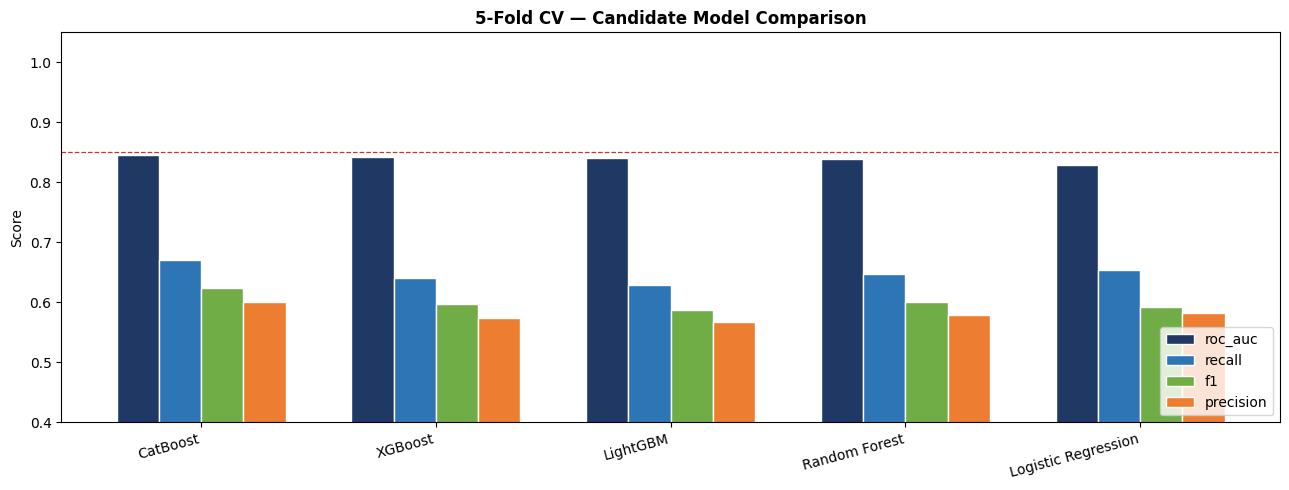

In [91]:
# Bar chart comparison


metrics_plot = ["roc_auc_mean", "recall_mean", "f1_mean", "precision_mean"]
model_names  = cv_df["Model"].tolist()
x      = np.arange(len(model_names))
width  = 0.18
colors = ["#1F3864", "#2E75B6", "#70AD47", "#ED7D31"]

fig, ax = plt.subplots(figsize=(13, 5))
for i, (m, c) in enumerate(zip(metrics_plot, colors)):
    offset = (i - len(metrics_plot)/2 + 0.5) * width
    ax.bar(x + offset, cv_df[m].values, width, label=m.replace("_mean",""),
           color=c, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.set_ylim(0.4, 1.05)
ax.set_ylabel("Score")
ax.set_title("5-Fold CV — Candidate Model Comparison", fontweight="bold")
ax.legend(loc="lower right")
ax.axhline(0.85, color="#C0392B", linestyle="--", linewidth=0.9, label="AUC target")
plt.tight_layout()
plt.show()


In [92]:
# After CV — resample once for final model training only

smote_final = SMOTE(k_neighbors=5, random_state=RANDOM_STATE)
X_train_res, y_train_res = smote_final.fit_resample(X_train, y_train)

print(f"Before SMOTE : {np.bincount(y_train)}   total = {len(y_train):,}")
print(f"After  SMOTE : {np.bincount(y_train_res)}   total = {len(y_train_res):,}")

Before SMOTE : [ 962 1071 5967]   total = 8,000
After  SMOTE : [5967 5967 5967]   total = 17,901


Best model: CatBoost
Mean Accuracy : 0.8009
Std  Accuracy : 0.0060


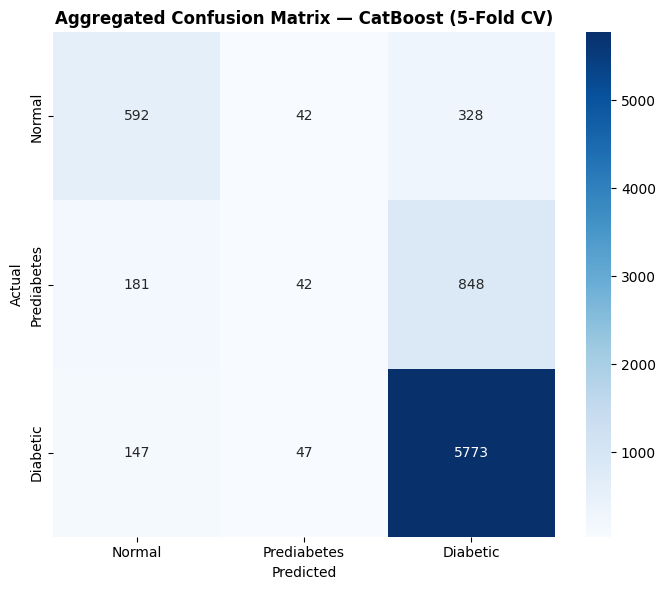

In [93]:
import copy

best_name  = cv_df.iloc[0]["Model"]
best_model = models[best_name]
print(f"Best model: {best_name}")

# 5-fold aggregated confusion matrix (3 classes)
final_cm   = np.zeros((3, 3), dtype=int)
accuracies = []

skf2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for train_idx, val_idx in skf2.split(X_train, y_train):
    Xf_tr, Xf_val = X_train[train_idx], X_train[val_idx]
    yf_tr, yf_val = y_train[train_idx], y_train[val_idx]

    fold_model = copy.deepcopy(best_model)
    fold_model.fit(Xf_tr, yf_tr)
    yf_hat = fold_model.predict(Xf_val)

    accuracies.append(accuracy_score(yf_val, yf_hat))
    final_cm += confusion_matrix(yf_val, yf_hat, labels=[0, 1, 2])

print(f"Mean Accuracy : {np.mean(accuracies):.4f}")
print(f"Std  Accuracy : {np.std(accuracies):.4f}")

class_labels = ["Normal", "Prediabetes", "Diabetic"]
plt.figure(figsize=(7, 6))
sns.heatmap(final_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Aggregated Confusion Matrix — {best_name} (5-Fold CV)", fontweight="bold")
plt.tight_layout()
plt.show()

In [94]:
import copy

final_model = copy.deepcopy(best_model)
final_model.fit(X_train_res, y_train_res)

y_val_prob = final_model.predict_proba(X_val)          # shape (n, 3)
y_val_pred = final_model.predict(X_val)

print("Validation Set Performance:")
print(f"  AUC-ROC (OvR macro) : {roc_auc_score(y_val, y_val_prob, multi_class='ovr', average='macro'):.4f}")
print(f"  Recall  (macro)     : {recall_score(y_val, y_val_pred, average='macro'):.4f}")
print(f"  Precision (macro)   : {precision_score(y_val, y_val_pred, average='macro', zero_division=0):.4f}")
print(f"  F1 (macro)          : {f1_score(y_val, y_val_pred, average='macro'):.4f}")
print(f"  Accuracy            : {accuracy_score(y_val, y_val_pred):.4f}")

Validation Set Performance:
  AUC-ROC (OvR macro) : 0.8394
  Recall  (macro)     : 0.6590
  Precision (macro)   : 0.5880
  F1 (macro)          : 0.6088
  Accuracy            : 0.7345


Optimal threshold for Diabetic class (Youden J = 0.6738): 0.3724
  Sensitivity : 0.8310
  Specificity : 0.8428

Risk bands (based on P(Diabetic)):
  Low      : P(Diabetic) < 0.3724
  Moderate : 0.3724 <= P(Diabetic) < 0.5724
  High     : P(Diabetic) >= 0.5724


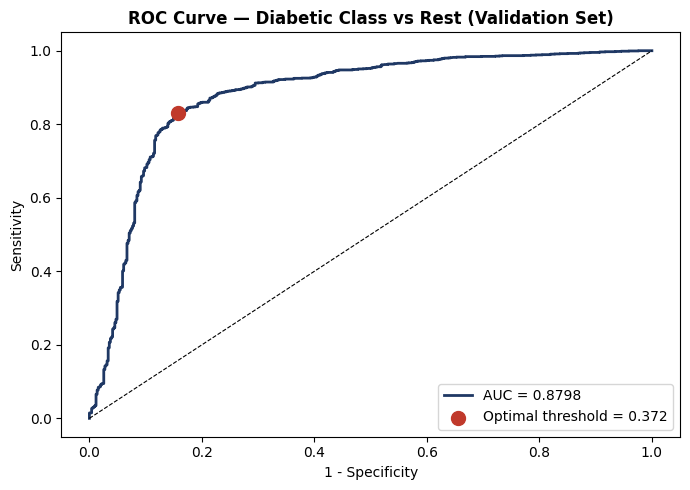

In [95]:
# Threshold tuning — binary OvR on the Diabetic class (class 2)
# We find the threshold on P(class=2) that maximises Youden J
# treating "Diabetic" as positive and "Normal+Prediabetes" as negative.

y_val_binary = (y_val == 2).astype(int)          # 1 = Diabetic, 0 = everything else
y_val_prob2  = y_val_prob[:, 2]                  # probability of class 2

fpr, tpr, thresholds = roc_curve(y_val_binary, y_val_prob2)
youden_j   = tpr - fpr
best_idx   = int(np.argmax(youden_j))
OPT_THRESH = float(thresholds[best_idx])

THRESH_LOW_HIGH = OPT_THRESH
THRESH_HIGH     = min(OPT_THRESH + 0.20, 0.90)

print(f"Optimal threshold for Diabetic class (Youden J = {youden_j[best_idx]:.4f}): {OPT_THRESH:.4f}")
print(f"  Sensitivity : {tpr[best_idx]:.4f}")
print(f"  Specificity : {1 - fpr[best_idx]:.4f}")
print()
print("Risk bands (based on P(Diabetic)):")
print(f"  Low      : P(Diabetic) < {THRESH_LOW_HIGH:.4f}")
print(f"  Moderate : {THRESH_LOW_HIGH:.4f} <= P(Diabetic) < {THRESH_HIGH:.4f}")
print(f"  High     : P(Diabetic) >= {THRESH_HIGH:.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color="#1F3864", linewidth=2,
        label=f"AUC = {roc_auc_score(y_val_binary, y_val_prob2):.4f}")
ax.scatter(fpr[best_idx], tpr[best_idx], color="#C0392B", s=100, zorder=5,
           label=f"Optimal threshold = {OPT_THRESH:.3f}")
ax.plot([0,1],[0,1],"k--",linewidth=0.8)
ax.set_xlabel("1 - Specificity")
ax.set_ylabel("Sensitivity")
ax.set_title("ROC Curve — Diabetic Class vs Rest (Validation Set)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

In [96]:
y_test_prob = final_model.predict_proba(X_test)     # shape (n, 3)
y_test_pred = final_model.predict(X_test)

test_auc  = roc_auc_score(y_test, y_test_prob, multi_class="ovr", average="macro")
test_rec  = recall_score(y_test, y_test_pred, average="macro")
test_prec = precision_score(y_test, y_test_pred, average="macro", zero_division=0)
test_f1   = f1_score(y_test, y_test_pred, average="macro")
test_acc  = accuracy_score(y_test, y_test_pred)

print("Test Set Performance:")
print(f"  AUC-ROC (OvR macro) : {test_auc:.4f}")
print(f"  Recall  (macro)     : {test_rec:.4f}")
print(f"  Precision (macro)   : {test_prec:.4f}")
print(f"  F1 (macro)          : {test_f1:.4f}")
print(f"  Accuracy            : {test_acc:.4f}")
print()
print(classification_report(y_test, y_test_pred,
                             target_names=["Normal (0)", "Prediabetes (1)", "Diabetic (2)"]))

Test Set Performance:
  AUC-ROC (OvR macro) : 0.8455
  Recall  (macro)     : 0.6761
  Precision (macro)   : 0.6058
  F1 (macro)          : 0.6252
  Accuracy            : 0.7350

                 precision    recall  f1-score   support

     Normal (0)       0.56      0.72      0.63       243
Prediabetes (1)       0.31      0.53      0.39       280
   Diabetic (2)       0.95      0.78      0.85      1477

       accuracy                           0.73      2000
      macro avg       0.61      0.68      0.63      2000
   weighted avg       0.81      0.73      0.76      2000



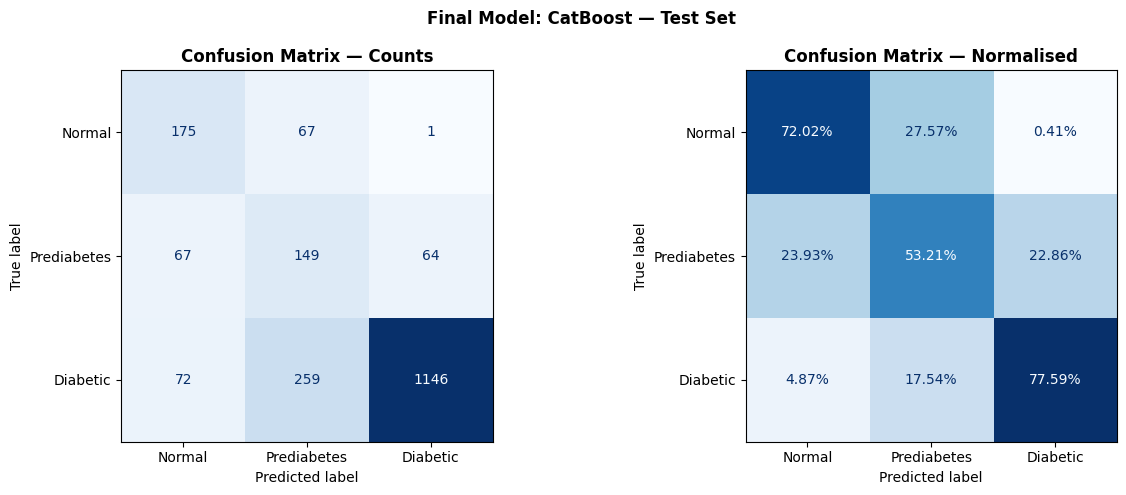

In [97]:
class_labels = ["Normal", "Prediabetes", "Diabetic"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1, 2])
ConfusionMatrixDisplay(cm, display_labels=class_labels) \
    .plot(ax=ax1, colorbar=False, cmap="Blues")
ax1.set_title("Confusion Matrix — Counts", fontweight="bold")

cm_norm = confusion_matrix(y_test, y_test_pred, labels=[0, 1, 2], normalize="true")
ConfusionMatrixDisplay(cm_norm, display_labels=class_labels) \
    .plot(ax=ax2, colorbar=False, cmap="Blues", values_format=".2%")
ax2.set_title("Confusion Matrix — Normalised", fontweight="bold")

plt.suptitle(f"Final Model: {best_name} — Test Set", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

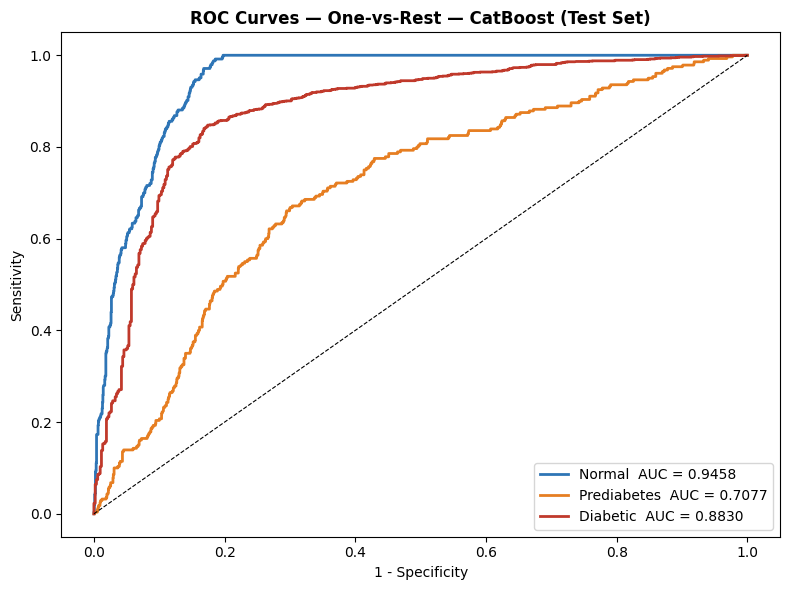

In [98]:
from sklearn.preprocessing import label_binarize

# Binarise y_test for per-class ROC plotting
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
class_labels = ["Normal", "Prediabetes", "Diabetic"]
class_colors = ["#2E75B6", "#E67E22", "#C0392B"]

fig, ax = plt.subplots(figsize=(8, 6))
for i, (label, color) in enumerate(zip(class_labels, class_colors)):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_test_prob[:, i])
    auc_i = roc_auc_score(y_test_bin[:, i], y_test_prob[:, i])
    ax.plot(fpr_i, tpr_i, color=color, linewidth=2, label=f"{label}  AUC = {auc_i:.4f}")

ax.plot([0,1],[0,1],"k--",linewidth=0.8)
ax.set_xlabel("1 - Specificity")
ax.set_ylabel("Sensitivity")
ax.set_title(f"ROC Curves — One-vs-Rest — {best_name} (Test Set)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

In [60]:
import copy

tree_models = ("XGBoost", "LightGBM", "CatBoost", "Random Forest")

if best_name in tree_models:
    explainer = shap.TreeExplainer(final_model)
else:
    explainer = shap.LinearExplainer(final_model, X_train,
                                     feature_perturbation="interventional")

N_SHAP    = min(1500, len(X_test))
shap_vals = explainer.shap_values(X_test[:N_SHAP])

# For 3-class tree models shap_values returns a list of 3 arrays (one per class)
# We use class 2 (Diabetic) for global importance — the highest-stakes class
if isinstance(shap_vals, list):
    shap_vals_diabetic = shap_vals[2]
else:
    shap_vals_diabetic = shap_vals

print(f"SHAP values shape (Diabetic class): {shap_vals_diabetic.shape}")

SHAP values shape (Diabetic class): (1500, 10, 3)


<Figure size 900x600 with 0 Axes>

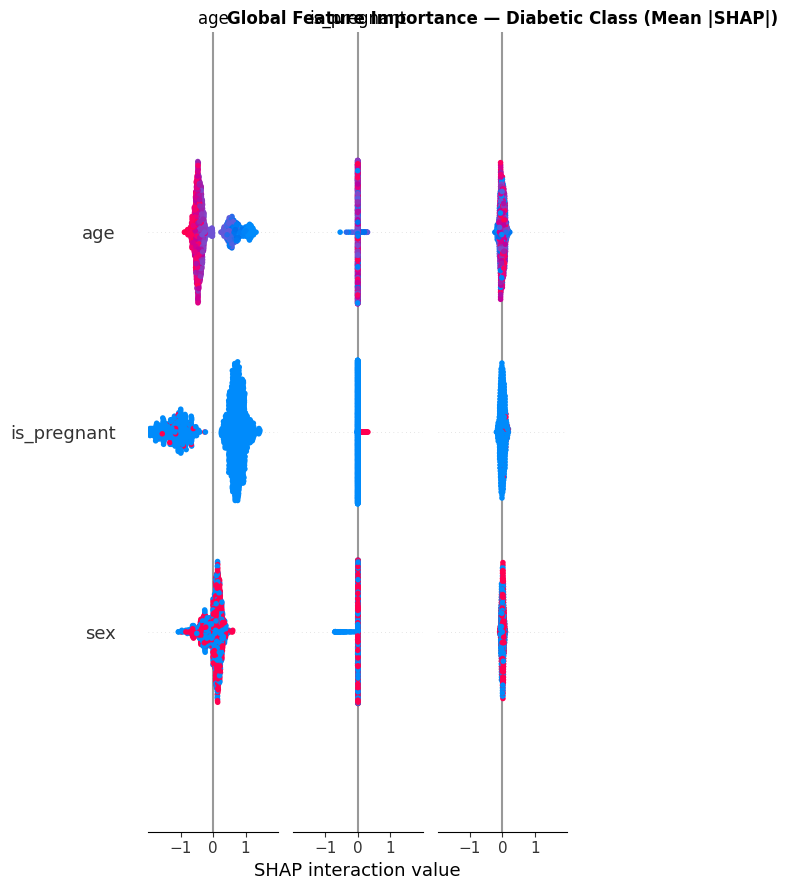

In [61]:
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_vals_diabetic,
    X_test[:N_SHAP],
    feature_names=np.array(FEATURE_COLS),
    plot_type="bar",
    show=False,
    color="#C0392B",
    max_display=len(FEATURE_COLS),
)
plt.title("Global Feature Importance — Diabetic Class (Mean |SHAP|)", fontweight="bold")
plt.tight_layout()
plt.show()

<Figure size 1000x700 with 0 Axes>

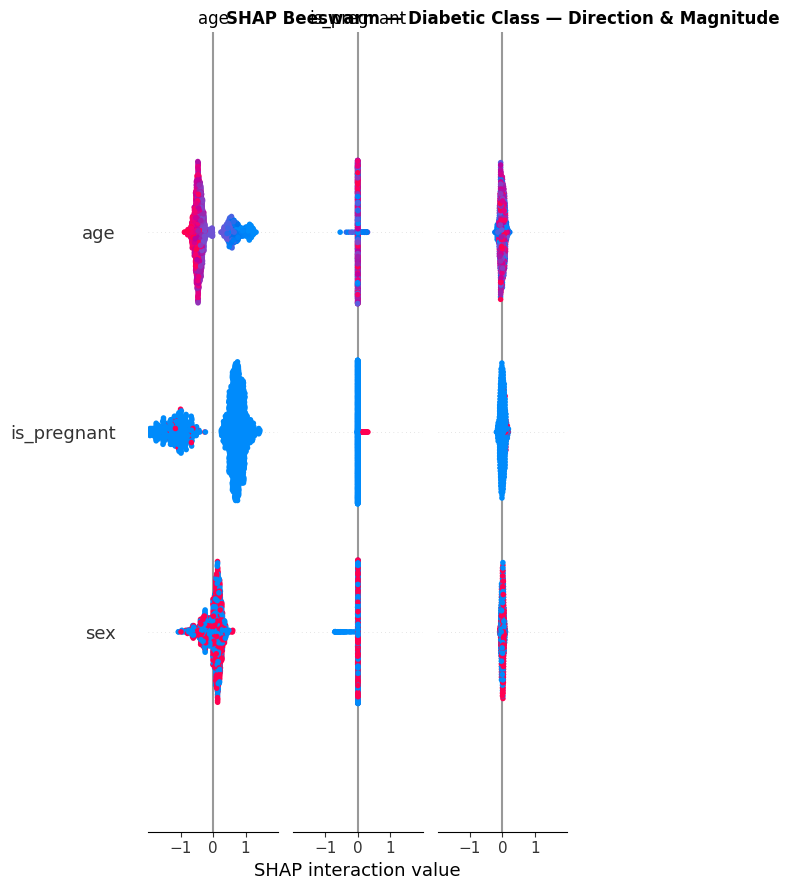

In [62]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_vals_diabetic,
    X_test[:N_SHAP],
    feature_names=np.array(FEATURE_COLS),
    show=False,
    max_display=len(FEATURE_COLS),
)
plt.title("SHAP Beeswarm — Diabetic Class — Direction & Magnitude", fontweight="bold")
plt.tight_layout()
plt.show()

### Hyperparameter Tuning using Optuna for best model(CatBoost)

In [65]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

def catboost_objective(trial):
    """
    Defines the search space and evaluation logic for one Optuna trial.
    Called once per trial. Returns the CV AUC-ROC to maximise.
    """
    params = {
        "iterations"         : trial.suggest_int("iterations",          100, 600),
        "learning_rate"      : trial.suggest_float("learning_rate",     0.01, 0.3,  log=True),
        "depth"              : trial.suggest_int("depth",               3,   10),
        "l2_leaf_reg"        : trial.suggest_float("l2_leaf_reg",       1e-3, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature",0.0,  1.0),
        "random_strength"    : trial.suggest_float("random_strength",   0.0,  1.0),
        "border_count"       : trial.suggest_int("border_count",        32,   255),
        "loss_function"      : "MultiClass",
        "random_seed"        : RANDOM_STATE,
        "verbose"            : 0,
    }

    model = CatBoostClassifier(**params)

    # SMOTE inside pipeline
    pipeline = ImbPipeline([
        ("smote", SMOTE(k_neighbors=5, random_state=RANDOM_STATE)),
        ("clf",   model)
    ])

    skf_opt = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    scores = cross_val_score(
        pipeline,
        X_train, y_train,          # original unbalanced data — SMOTE handles it
        cv=skf_opt,
        scoring="roc_auc_ovr",
        n_jobs=-1,
    )
    return scores.mean()


# Create and run the study
# direction="maximize" → Optuna tries to increase AUC-ROC each trial
# TPESampler → smarter than random search; learns from previous trials
# n_trials=50 → tests 50 hyperparameter combinations

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10),
)

print("Running Optuna — 50 trials.")
study.optimize(catboost_objective, n_trials=50, show_progress_bar=True)

print(f"\n Best CV AUC-ROC : {study.best_value:.4f}")
print(f"   Best parameters :")
for k, v in study.best_params.items():
    print(f"     {k:<25}: {v}")

Running Optuna — 50 trials.


  0%|          | 0/50 [00:00<?, ?it/s]


 Best CV AUC-ROC : 0.8486
   Best parameters :
     iterations               : 366
     learning_rate            : 0.05871244070373906
     depth                    : 6
     l2_leaf_reg              : 2.1329613607972666
     bagging_temperature      : 0.20616356966474197
     random_strength          : 0.01676983095338097
     border_count             : 243


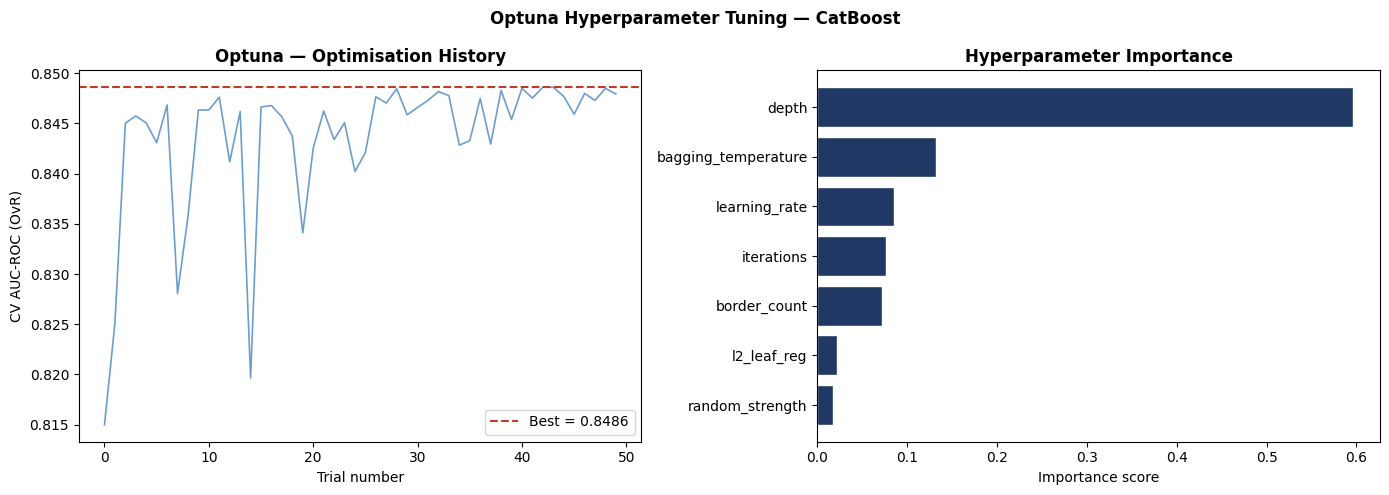

In [66]:
# Visualise Optuna results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Optimisation history — shows how AUC improved across trials
trial_values = [t.value for t in study.trials if t.value is not None]
axes[0].plot(trial_values, color="#2E75B6", linewidth=1.2, alpha=0.7)
axes[0].axhline(study.best_value, color="#C0392B", linestyle="--", linewidth=1.5,
                label=f"Best = {study.best_value:.4f}")
axes[0].set_xlabel("Trial number")
axes[0].set_ylabel("CV AUC-ROC (OvR)")
axes[0].set_title("Optuna — Optimisation History", fontweight="bold")
axes[0].legend()

# Hyperparameter importance — which params mattered most

importance = optuna.importance.get_param_importances(study)
axes[1].barh(list(importance.keys()), list(importance.values()),
             color="#1F3864", edgecolor="white")
axes[1].set_xlabel("Importance score")
axes[1].set_title("Hyperparameter Importance", fontweight="bold")
axes[1].invert_yaxis()

plt.suptitle("Optuna Hyperparameter Tuning — CatBoost", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [67]:
# Retrain tuned model on resampled training set
tuned_catboost = CatBoostClassifier(
    **study.best_params,
    loss_function="MultiClass",
    random_seed=RANDOM_STATE,
    verbose=0,
)
tuned_catboost.fit(X_train_res, y_train_res)

# Evaluate on validation set
y_val_prob_tuned = tuned_catboost.predict_proba(X_val)
y_val_pred_tuned = tuned_catboost.predict(X_val)

val_auc_tuned = roc_auc_score(y_val, y_val_prob_tuned, multi_class="ovr", average="macro")
val_rec_tuned = recall_score(y_val, y_val_pred_tuned, average="macro")
val_f1_tuned  = f1_score(y_val, y_val_pred_tuned, average="macro")

print("Tuned CatBoost — Validation Set:")
print(f"  AUC-ROC (macro) : {val_auc_tuned:.4f}")
print(f"  Recall  (macro) : {val_rec_tuned:.4f}")
print(f"  F1      (macro) : {val_f1_tuned:.4f}")

Tuned CatBoost — Validation Set:
  AUC-ROC (macro) : 0.8392
  Recall  (macro) : 0.6486
  F1      (macro) : 0.6092


In [ ]:
# Evaluate on test set
y_test_prob_tuned = tuned_catboost.predict_proba(X_test)
y_test_pred_tuned = tuned_catboost.predict(X_test)

test_auc_tuned = roc_auc_score(y_test, y_test_prob_tuned, multi_class="ovr", average="macro")
test_rec_tuned = recall_score(y_test, y_test_pred_tuned, average="macro")
test_f1_tuned  = f1_score(y_test, y_test_pred_tuned, average="macro")
test_acc_tuned = accuracy_score(y_test, y_test_pred_tuned)

print(f"\nTuned CatBoost — Test Set:")
print(f"  AUC-ROC (macro) : {test_auc_tuned:.4f}  (baseline: {test_auc:.4f})")
print(f"  Recall  (macro) : {test_rec_tuned:.4f}  (baseline: {test_rec:.4f})")
print(f"  F1      (macro) : {test_f1_tuned:.4f}  (baseline: {test_f1:.4f})")
print(f"  Accuracy        : {test_acc_tuned:.4f}  (baseline: {test_acc:.4f})")

print()
print(classification_report(y_test, y_test_pred_tuned,
                             target_names=["Normal (0)", "Prediabetes (1)", "Diabetic (2)"]))




Tuned CatBoost — Test Set:
  AUC-ROC (macro) : 0.8440  (baseline: 0.8455)
  Recall  (macro) : 0.6406  (baseline: 0.6761)
  F1      (macro) : 0.6043  (baseline: 0.6252)
  Accuracy        : 0.7405  (baseline: 0.7350)

                 precision    recall  f1-score   support

     Normal (0)       0.53      0.69      0.60       243
Prediabetes (1)       0.29      0.42      0.35       280
   Diabetic (2)       0.93      0.81      0.87      1477

       accuracy                           0.74      2000
      macro avg       0.59      0.64      0.60      2000
   weighted avg       0.79      0.74      0.76      2000



### Save Model

since the baseline catboot model performed better than the turned catboot model, the baseline will be saved

In [99]:
import os

MODEL_DIR = "../data/06_models"
os.makedirs(MODEL_DIR, exist_ok=True)

final_model.save_model(
    f"{MODEL_DIR}/catboost_model.cbm"
)

In [100]:
print(best_name)
print(final_model)

CatBoost
CatBoostClassifier(depth=6, iterations=200, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=0)


In [101]:
# load final model

model = CatBoostClassifier()
model.load_model(
    "../data/06_models/catboost_model.cbm"
)

CatBoostClassifier(depth=6, iterations=200, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=0)